<a href="https://colab.research.google.com/github/Victoria-Yiquan-Wang/From-Lehman-to-COVID-to-SVB-Evolving-Crisis-Narratives-in-Financial-News/blob/main/From_Lehman_to_COVID_to_SVB_Evolving_Crisis_Narratives_in_Financial_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Lehman to COVID to SVB: Evolving Crisis Narratives in Financial News

## 1. Introduction

Financial crises are not only economic events; they are also narrative events that are framed and interpreted through the media. News coverage can shape how policymakers, investors, and the broader public perceive the severity, causes, and potential remedies of a crisis. In this project, I analyze how English-language financial news describes three major episodes of market stress in the United States: the 2008 global financial crisis surrounding the collapse of Lehman Brothers, the 2020 market shock triggered by the COVID-19 pandemic, and the 2023 regional banking turmoil associated with Silicon Valley Bank and other institutions. Although these crises differ in their economic impact and policy response, they are all moments when media narratives and sentiment may influence expectations and behavior in financial markets.

The goal of this project is to examine whether the tone and framing of crisis coverage evolve over time, and how closely news sentiment aligns with the underlying severity of each episode.I focus on three episodes:

- **2008 Global Financial Crisis** (Lehman Brothers collapse)  
- **2020 COVID-19 market shock**  
- **2023 U.S. regional banking turmoil** (e.g., Silicon Valley Bank)

Intuitively, we might expect the 2008 crisis—often viewed as the most systemic and damaging—to be covered in the most negative tone, followed by the COVID-19 shock and, finally, the more contained 2023 banking stress. At the same time, the language of crisis may have shifted from a focus on individual failing institutions (such as Lehman Brothers, Merrill Lynch, or AIG) toward a more system-level emphasis on deposits, regulators, and financial stability. Understanding these shifts is relevant for policy because media narratives can amplify or dampen perceived systemic risk and may influence the political appetite for interventions such as bailouts, liquidity facilities, and deposit guarantees.

To study these questions, I collect a small sample of news articles from the Factiva database for each of the three crisis periods [(Krisel, 2025)](https://github.com/SIPA-Text-Analysis-F25/syllabus/blob/main/README.md)
. For every article, I construct a combined text field from the lead paragraph and body, and I assign each article to one of three periods: “2008_crisis,” “2020_covid,” and “2023_banking,” based on its publication date and content. I then use VADER, a rule-based sentiment analysis tool for English, and FinBERT, a sentiment analysis tool build especially for financial articles, to measure both article-level and sentence-level sentiment, summarizing the average tone within each period. In addition, I apply FreqList and TF–IDF weighting to identify the most distinctive keywords that characterize each crisis episode. Together, these tools allow me to compare not just how negative the coverage is across crises, but also how the underlying narratives shift from firm-level failures to broader concerns about systemic fragility and regulatory response, and then analyzed the implications for policy makers.



## 2. Research Questions

1. How negative is financial-crisis news coverage in different episodes?
Do news articles become more emotionally negative in more severe crises?

2. Does the sentiment ranking of the three crises (2008, 2020, 2023) match their actual economic severity?
In terms of real-world impact, we would usually rank them as: 2008 > 2020 > 2023. Does the news sentiment follow the same order?

3. How do the dominant narratives and keywords differ across crises?
I use TF–IDF to highlight the distinctive terms by period and investivate the change over time.

## 3. Data Collection

I collected news articles from **Factiva**, accessed through the Columbia University Libraries database portal. For each crisis episode, I ran a targeted search and manually selected a small sample of articles (16-18 per period, 52 in total):

- **2008 crisis:**
  - Key Words: (“financial crisis” OR "credit crunch" OR "market meltdown" OR "global crisis") AND (“Lehman” OR "investment bank" OR "bailout" OR "subprime mortgage")
  - Time: from 2008-09-01 to 2009-03-31

- **2020 COVID:**
  - Key Words: ("market crash" OR "market turmoil" OR "recession" OR "economic downturn") AND ("COVID" OR "pandemic" OR "coronavirus" OR "lockdown")
  - Time: from 2020-02-15 to 2020-08-31

- **2023 banking turmoil:**
  - Key Words: ("banking crisis" OR "bank run" OR "bank collapse" OR "financial stability") AND ("Silicon Valley Bank" OR SVB OR "regional banks" OR "First Republic" OR "Credit Suisse")
  - Time: from 2023-03-01 to 2023-09-30

Then I stored the html code into three htm document, here I only showed the processing of the three htm document, because the html code is very long and hard to read.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob # used to find all the file paths that match a specified pattern
import pandas as pd
import os

In [3]:
path = "/content/drive/MyDrive/Text Analysis in Python"
files = glob.glob(f"{path}/*.htm", recursive = True) #replace with your path
files

['/content/drive/MyDrive/Text Analysis in Python/factiva_0.htm',
 '/content/drive/MyDrive/Text Analysis in Python/factiva_1.htm',
 '/content/drive/MyDrive/Text Analysis in Python/factiva_2.htm']

In [4]:
empty_list = []
for file in files:
    data = pd.read_html(file, index_col = 0) #reads the HTML content of the file and tries to find any tables inside it.
    empty_list.extend(data) # The extend() method is used to add the data (which is a list of dataframes) from the current file to empty_list.
files

['/content/drive/MyDrive/Text Analysis in Python/factiva_0.htm',
 '/content/drive/MyDrive/Text Analysis in Python/factiva_1.htm',
 '/content/drive/MyDrive/Text Analysis in Python/factiva_2.htm']

In [5]:
# frames contains a dataframe where all relevant dataframes (those containing 'HD' in their index) are combined and flipped.
frames = pd.concat([l for l in empty_list if 'HD' in l.index.values], axis=1).T
frames.head()

,SE,HD,BY,CR,WC,PD,ET,SN,SC,LA,...,IN,NS,RE,IPD,PUB,AN,CLM,CO,PG,IPC
1,News &Commentary,Milestones in the meltdown,"William L. Watts, MarketWatch",MarketWatch; mailto:bwatts@marketwatch.com; Wi...,2129 words,13 March 2009,01:01 PM,MarketWatch,MRKWC,English,...,ibnk : Banking/Credit,e52 : Euro Zone/Currency | m12 : Debt/Bond Mar...,fra : France | jap : Japan | uk : United Kingd...,News &Commentary|Economy and Politics | Bond M...,"Dow Jones & Company, Inc.",Document MRKWC00020090313e53d002ut,NaN,NaN,NaN,NaN
1,Personal Finance,Financial Spider weaves a tangled web; Sector ...,"John Spence, MarketWatch",MarketWatch; mailto:jspence@marketwatch.com; J...,1664 words,1 October 2008,02:00 PM,MarketWatch,MRKWC,English,...,i81502 : Trusts/Funds/Financial Vehicles | iin...,m11 : Equity Markets | mcat : Commodity/Financ...,usa : United States | namz : North America,Personal Finance|Mutual Funds | Mutual Funds |...,"Dow Jones & Company, Inc.",Document MRKWC00020081001e4a10040h,ETF Focus,finspd : Select Sector SPDR-Financial Fund,NaN,NaN
1,NaN,Year-End Review of Markets &Finance 2008 --- S...,NaN,NaN,10960 words,2 January 2009,NaN,The Wall Street Journal,J,English,...,i814 : Banking | i81501 : Credit Types/Service...,c1521 : Analyst Comment/Recommendation | e1201...,usa : United States | nyc : New York City | uk...,NaN,"Dow Jones & Company, Inc.",Document J000000020090102e51200029,NaN,berstn : The Bear Stearns Companies LLC | dwit...,R9,MMR | NND | MNO | SPE
1,Business,The Weekend That Wall Street Died; Ties That L...,"By Susanne Craig, Jeffrey McCracken, Aaron Luc...",NaN,4658 words,29 December 2008,NaN,The Wall Street Journal (Online and Print),WSJO,English,...,i835 : Legal Services | i831 : Financial Inves...,e512 : Physical Trade | mcat : Commodity/Finan...,usa : United States | nyc : New York City | uk...,Richard Fuld | Kenneth D. Lewis | John Mack | ...,"Dow Jones & Company, Inc.",Document WSJO000020091007e4ct00mu7,NaN,barc : Barclays PLC | lehbro : Lehman Brothers...,Business; A1,NaN
1,NaN,Unraveled ties marked death of Wall Street,"By Susanne Craig, Jeffrey McCracken, Aaron Luc...",NaN,4620 words,30 December 2008,NaN,The Wall Street Journal Europe,WSJE,English,...,i831 : Financial Investments | iinv : Investin...,c13 : Regulation/Government Policy | c1521 : A...,eurz : Europe | nyc : New York City | uk : Uni...,NaN,"Dow Jones & Company, Inc.",Document WSJE000020081230e4cu0001t,NaN,barc : Barclays PLC | lehbro : Lehman Brothers...,1,BKG | CMR | DJCB | EWR | FED | SEC | TRE | USG...


Take a look at the columns in our `frames` dataframe. The columns correspond to the index on the left column of the print view of articles in Factiva.

In [6]:
frames.columns

Index(['SE', 'HD', 'BY', 'CR', 'WC', 'PD', 'ET', 'SN', 'SC', 'LA', 'CY', 'LP',
       'TD', 'RF', 'IN', 'NS', 'RE', 'IPD', 'PUB', 'AN', 'CLM', 'CO', 'PG',
       'IPC'],
      dtype='object', name=0)

## 4. Data Cleaning
First, rename certain columns to more meaningful or readable names (e.g., 'HD' becomes 'Headline', 'PD' becomes 'Publication_Date', etc.) and select only the relevant columns we want to keep.

In [7]:
frames.rename(columns = {'HD': 'Headline',
                         'PD': 'Publication_Date','SN': 'Source_Name', 'LP': 'Lead Paragraph',
                          'TD': 'Body',
                         'BY':'Author_Name'}, inplace=True)

frames = frames[['Headline', 'Publication_Date', 'Source_Name', 'Lead Paragraph', 'Body', 'Author_Name']]


In [8]:
frames['Publication_Date'] = pd.to_datetime(frames['Publication_Date'])
frames.sort_values(by='Publication_Date', inplace=True)

In [9]:
frames['CombinedText'] = frames['Lead Paragraph'] + " " + frames['Body']
frames

,Headline,Publication_Date,Source_Name,Lead Paragraph,Body,Author_Name,CombinedText
1,Potential Lehman buyers balking; Unwilling to ...,2008-09-14,MarketWatch,WASHINGTON (MarketWatch) -- Barclays PLC and B...,Although Barclays and Bank of America emerged ...,MarketWatch,WASHINGTON (MarketWatch) -- Barclays PLC and B...
1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008-09-15,Dow Jones Institutional News,(updates throughout to incorporate Obama backg...,Nick Timiraos reports. As the financial crisi...,NaN,(updates throughout to incorporate Obama backg...
1,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008-09-15,Dow Jones Institutional News,European and Asian stock markets and the U.S. ...,=WSJ:LEHMAN TO FILE FOR PROTECTION UNDER CHAPT...,NaN,European and Asian stock markets and the U.S. ...
1,European Bank Shares Seen Lower After Lehman C...,2008-09-15,Dow Jones International News,European bank shares are seen under renewed se...,"Meanwhile, Lehman's expected savior, Bank of A...",By Digby Larner,European bank shares are seen under renewed se...
1,Lehman files for bankruptcy protection; Wall S...,2008-09-15,MarketWatch,NEW YORK (MarketWatch) -- Wall Street struggle...,Lehman said that it will continue business whi...,MarketWatch,NEW YORK (MarketWatch) -- Wall Street struggle...
1,"AIG Bailout Prompts Political Finger Pointing,...",2008-09-17,Dow Jones International News,WASHINGTON (Dow Jones)--The Federal Reserve's ...,"The AIG intervention, and the recent takeover ...",By Henry J. Pulizzi,WASHINGTON (Dow Jones)--The Federal Reserve's ...
1,Street Scenes: The Players Remaking Financial ...,2008-09-19,The Wall Street Journal Online,History has thrown a handful of men together t...,It's too early to know whether the choices the...,"By Susanne Craig, Carrick Mollenkamp, Deborah ...",History has thrown a handful of men together t...
1,News in Depth: The Financial Crisis: Street sc...,2008-09-22,The Wall Street Journal Asia,HISTORY HAS THROWN a handful of men together t...,It is too early to know whether the choices th...,"By Susanne Craig, Carrick Mollenkamp, Deborah ...",HISTORY HAS THROWN a handful of men together t...
1,News Highlights: Top Equities Stories Of The Day,2008-09-22,Dow Jones News Service,"TOP STORIES GOLDMAN, MORGAN SCRAP WALL STREET ...",US STOCK FUTURES DOWN AS INVESTORS MULL GOVERN...,NaN,"TOP STORIES GOLDMAN, MORGAN SCRAP WALL STREET ..."
1,Lehman's Demise Triggered Cash Crunch Around G...,2008-09-29,The Wall Street Journal Online,Decision to Let Firm Fail Marked a Turning Poi...,"Now, the consequences of that decision look mo...",By Carrick Mollenkamp and Mark Whitehouse in L...,Decision to Let Firm Fail Marked a Turning Poi...


In [10]:
df = frames.reset_index()

In df, I labeled each article by crisis period (2008, 2020, 2023)

In [11]:
# Make sure Publication_Date is in datetime format
df["Publication_Date"] = pd.to_datetime(df["Publication_Date"], errors="coerce")

# drop rows where the date could not be parsed
df = df[df["Publication_Date"].notna()].copy()

df["Publication_Date"].head(), df["Publication_Date"].dtype

def label_period(date):
    """
    Assign each article to a crisis period based on its publication date.
    Adjust the date ranges if they differ from your actual Factiva search windows.
    """
    if date.year == 2008 or (date.year == 2009 and date.month <= 3):
        return "2008_crisis"
    elif date.year == 2020:
        return "2020_covid"
    elif date.year == 2023:
        return "2023_banking"
    else:
        return "other"

# Apply the period label
df["period"] = df["Publication_Date"].apply(label_period)

# Keep only the three periods of interest
df = df[df["period"] != "other"].copy()

df.head()


,index,Headline,Publication_Date,Source_Name,Lead Paragraph,Body,Author_Name,CombinedText,period
0,1,Potential Lehman buyers balking; Unwilling to ...,2008-09-14,MarketWatch,WASHINGTON (MarketWatch) -- Barclays PLC and B...,Although Barclays and Bank of America emerged ...,MarketWatch,WASHINGTON (MarketWatch) -- Barclays PLC and B...,2008_crisis
1,1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008-09-15,Dow Jones Institutional News,(updates throughout to incorporate Obama backg...,Nick Timiraos reports. As the financial crisi...,NaN,(updates throughout to incorporate Obama backg...,2008_crisis
2,1,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008-09-15,Dow Jones Institutional News,European and Asian stock markets and the U.S. ...,=WSJ:LEHMAN TO FILE FOR PROTECTION UNDER CHAPT...,NaN,European and Asian stock markets and the U.S. ...,2008_crisis
3,1,European Bank Shares Seen Lower After Lehman C...,2008-09-15,Dow Jones International News,European bank shares are seen under renewed se...,"Meanwhile, Lehman's expected savior, Bank of A...",By Digby Larner,European bank shares are seen under renewed se...,2008_crisis
4,1,Lehman files for bankruptcy protection; Wall S...,2008-09-15,MarketWatch,NEW YORK (MarketWatch) -- Wall Street struggle...,Lehman said that it will continue business whi...,MarketWatch,NEW YORK (MarketWatch) -- Wall Street struggle...,2008_crisis


After cleaning and merging, I obtain a DataFrame df with one row per article:

- `Headline`  
- `Publication_Date`  
- `Source_Name`  
- `Lead Paragraph`  
- `Body`  
- `CombinedText` = Lead Paragraph + Body  
- `period` = {`2008_crisis`, `2020_covid`, `2023_banking`}  
  
Then, I saved the final df after data cleaning into my drive, so I can read the df and analyse data without doing everything again. I also saved each news articles into one txt file.


In [12]:
save_path = os.path.join(path, "factiva.csv")
df.to_csv(save_path, index=False)

In [13]:
for index, row in df.iterrows():
    file_name = f"{path}/factiva_ner_project/text_file_{index + 1}.txt"  # Create a unique filename for each row
    with open(file_name, 'w') as file:
        text_content = str(row['CombinedText']) if pd.notnull(row['CombinedText']) else ''  # Convert to string and handle NaN
        file.write(text_content)  # Write the text content to the file

## 5. Sentiment Analysis: VADER and finBERT

### 5.1 VADER: Article- and Sentence-Level

In this section, I use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to quantify the tone of crisis coverage in the news articles [(Krisel, 2025)](https://github.com/SIPA-Text-Analysis-F25/syllabus/blob/main/README.md). For every article, I take the combined lead paragraph + body (`CombinedText`) and compute a compound sentiment score in \[-1, 1\], stored as `sentiment`. I also score the headline separately (`headline_sentiment`) to compare how titles and full-text tone may differ.

To get a finer-grained view, I move to the sentence level. I split each article into sentences, run VADER on each sentence, and then summarize three statistics per article: the average sentence score (`sent_mean_compound`), the share of negative sentences (`sent_pct_neg`), and the number of sentences (`n_sents`). This helps control for very long articles and shows how much of each story is framed in negative language.

Finally, I aggregate these metrics by crisis period (`2008_crisis`, `2020_covid`, `2023_banking`). For each period, I compute the number of articles, average and median article-level sentiment, the share of positive/negative/neutral articles, and the average sentence-level statistics. The resulting summary table (`sent_summary`) is the basis for my comparison of how crisis narratives evolve over time.


In [14]:
# Keep pandas (already in Colab). Ensure latest NLTK.
# !pip -q install --upgrade nltk

import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download the VADER lexicon (only needs to run once per runtime)
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [15]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
# pd.set_option('display.max_colwidth',None)
# pd.set_option('display.width',None)
# save_path = os.path.join(path, "factiva.csv")

path = "/content/drive/MyDrive/Text Analysis in Python"
csv_path = os.path.join(path, "factiva.csv")
# df = pd.read_csv(csv_path)

In [16]:
def compound_score(text):
    """
    Return the VADER compound sentiment score in [-1, 1] for a given text string.
    Higher values indicate more positive sentiment; lower values indicate more negative sentiment.
    """
    return sia.polarity_scores(text or "")["compound"]

# Compute sentiment scores for each article's full text
df["sentiment"] = df["CombinedText"].astype(str).apply(compound_score)

# Optionally, compute sentiment scores for headlines only
df["headline_sentiment"] = df["Headline"].astype(str).apply(compound_score)

# Quick check
df[["Headline", "Publication_Date", "sentiment", "headline_sentiment"]].head()

,Headline,Publication_Date,sentiment,headline_sentiment
0,Potential Lehman buyers balking; Unwilling to ...,2008-09-14,-0.9636,0.0000
1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008-09-15,0.9900,0.0000
2,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008-09-15,-0.5624,0.0000
3,European Bank Shares Seen Lower After Lehman C...,2008-09-15,-0.9748,-0.4939
4,Lehman files for bankruptcy protection; Wall S...,2008-09-15,-0.9089,0.0000


In [17]:
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

# We already have POS, NEG thresholds defined; reuse NEG here
POS, NEG = 0.05, -0.05  # if not defined yet, define them once

def sentence_level_stats(text):
    """
    Compute sentence-level sentiment statistics for a single article.
    Returns:
      - sent_mean_compound: average VADER compound across sentences
      - sent_pct_neg: share of negative sentences (compound < NEG)
      - n_sents: number of sentences
    """
    text = str(text)
    sents = sent_tokenize(text)
    if not sents:
        return pd.Series(
            [None, None, 0],
            index=["sent_mean_compound", "sent_pct_neg", "n_sents"]
        )

    scores = [sia.polarity_scores(s)["compound"] for s in sents]
    mean_c = sum(scores) / len(scores)
    pct_neg = sum(1 for c in scores if c < NEG) / len(scores)

    return pd.Series(
        [mean_c, pct_neg, len(sents)],
        index=["sent_mean_compound", "sent_pct_neg", "n_sents"]
    )

# Apply to each article's full text
df[["sent_mean_compound", "sent_pct_neg", "n_sents"]] = \
    df["CombinedText"].apply(sentence_level_stats)

df[["Headline", "period", "sentiment", "sent_mean_compound", "sent_pct_neg"]].head()


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Headline,period,sentiment,sent_mean_compound,sent_pct_neg
0,Potential Lehman buyers balking; Unwilling to ...,2008_crisis,-0.9636,-0.071653,0.425532
1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008_crisis,0.9900,0.095304,0.208333
2,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008_crisis,-0.5624,-0.025118,0.352941
3,European Bank Shares Seen Lower After Lehman C...,2008_crisis,-0.9748,-0.066644,0.400000
4,Lehman files for bankruptcy protection; Wall S...,2008_crisis,-0.9089,-0.018896,0.270833


In [18]:
# Standard VADER thresholds for positive / negative / neutral
POS, NEG = 0.05, -0.05

# Article-level sentiment label
df["sentiment_label"] = df["sentiment"].apply(
    lambda c: "pos" if c > POS else ("neg" if c < NEG else "neu")
)

# Group by period and compute summary statistics
sent_summary = (
    df.groupby("period")
      .agg(
          n_articles=("Headline", "count"),                 # number of articles

          # Article-level sentiment
          mean_compound=("sentiment", "mean"),
          median_compound=("sentiment", "median"),
          pct_pos=("sentiment_label", lambda s: (s == "pos").mean()),
          pct_neg=("sentiment_label", lambda s: (s == "neg").mean()),
          pct_neu=("sentiment_label", lambda s: (s == "neu").mean()),

          # Sentence-level sentiment (new)
          mean_sent_mean=("sent_mean_compound", "mean"),      # avg of per-article sentence means
          mean_sent_pct_neg=("sent_pct_neg", "mean"),         # avg share of negative sentences
          mean_n_sents=("n_sents", "mean")                    # average # of sentences per article
      )
      .reset_index()
)

# Format the summary table
sent_summary["mean_compound"] = sent_summary["mean_compound"].round(3)
sent_summary["median_compound"] = sent_summary["median_compound"].round(3)
sent_summary["pct_pos"] = (sent_summary["pct_pos"] * 100).round(1)
sent_summary["pct_neg"] = (sent_summary["pct_neg"] * 100).round(1)
sent_summary["pct_neu"] = (sent_summary["pct_neu"] * 100).round(1)

sent_summary["mean_sent_mean"] = sent_summary["mean_sent_mean"].round(3)
sent_summary["mean_sent_pct_neg"] = (sent_summary["mean_sent_pct_neg"] * 100).round(1)
sent_summary["mean_n_sents"] = sent_summary["mean_n_sents"].round(1)

sent_summary


,period,n_articles,mean_compound,median_compound,pct_pos,pct_neg,pct_neu,mean_sent_mean,mean_sent_pct_neg,mean_n_sents
0,2008_crisis,16,-0.044,-0.325,43.8,56.2,0.0,-0.023,34.5,129.2
1,2020_covid,19,-0.158,-0.993,42.1,57.9,0.0,-0.013,36.1,304.4
2,2023_banking,18,-0.423,-0.988,27.8,72.2,0.0,-0.033,34.6,130.8


### 5.2 Plotly Visualization of VADER Sentiment Analysis
I plot two sets of bar charts to compare news tone across the three crisis episodes:

- **Passage-level sentiment:** The first chart uses the VADER *article-level* compound score (`mean_compound`) averaged within each period. This treats each article as a single document and summarizes its overall tone.
- **Sentence-level sentiment:** The second chart uses the *sentence-level* average (`mean_sent_mean`), where I first score each sentence and then average across sentences within each article and period. This helps control for very long articles and gives a finer-grained view of tone.

From the sentence-level chart, I find that:
1. The average sentiment in all three periods is close to zero, indicating that financial news maintains a relatively neutral, restrained tone even during crises.
2. In terms of actual systemic severity, we usually rank the crises as **2008 > 2020 > 2023**, but the **news sentiment negative ranking is 2023 > 2008 > 2020** . This mismatch suggests that media tone does not map one-to-one onto macro severity. To explain this, I use TF_IDF in the next section, which gave us a possible explaination.

In [19]:
# !pip uninstall -y plotly
# !pip install -q plotly kaleido

In [20]:
# Install Plotly + Kaleido (for saving static PNGs)
# !pip -q install --upgrade plotly kaleido

import plotly.express as px
import plotly.io as pio

# Set a renderer suitable for Colab. Alternatives: 'notebook_connected', 'svg', 'png'
pio.renderers.default = "colab"

passage level sentiment analysis and visualization

In [21]:
# --- 1) Bar chart: passage level average sentiment ---
if 'sent_summary' in globals() and not sent_summary.empty and sent_summary['mean_compound'].notna().any():

    period_order = ["2008_crisis", "2020_covid", "2023_banking"]

    plot_df = (
        sent_summary
        .set_index("period")
        .loc[[p for p in period_order if p in sent_summary["period"].unique()]]
        .reset_index()
    )

    label_map = {
        "2008_crisis": "2008 Crisis",
        "2020_covid": "2020 COVID Shock",
        "2023_banking": "2023 Banking Turmoil"
    }
    plot_df["period_label"] = plot_df["period"].map(label_map).fillna(plot_df["period"])

    plot_df["mean_compound_rounded"] = plot_df["mean_compound"].round(3)

    fig_bar = px.bar(
        plot_df,
        x="period_label",
        y="mean_compound",
        text="mean_compound_rounded",
        hover_data={
            "period": True,
            "n_articles": True,
            "mean_compound": ':.3f',
            "median_compound": ':.3f',
            "pct_pos": ':.1f',
            "pct_neg": ':.1f',
            "pct_neu": ':.1f',
        },
        title="Average Sentiment of Crisis Coverage by Period",
        labels={
            "period_label": "Crisis period",
            "mean_compound": "Average VADER compound score",
        },
    )

    fig_bar.update_traces(
        textposition="outside",
        textfont=dict(size=14)
    )

    fig_bar.update_layout(
        xaxis_title="Crisis period",
        yaxis_title="Average VADER compound score",
        bargap=0.6,
        font=dict(size=16),
        margin=dict(t=80, b=80, l=60, r=40)
    )
    fig_bar.update_layout(
        xaxis_title="Crisis period",
        yaxis_title="Average VADER compound score",
        bargap=0.6,
        font=dict(size=16),
        margin=dict(t=60, b=60, l=60, r=40),
        width=700,
        height=350
    )

    y_min = min(plot_df["mean_compound"]) * 1.1
    y_max = max(plot_df["mean_compound"]) * 0.9 if max(plot_df["mean_compound"]) < 0 else max(plot_df["mean_compound"]) * 1.1
    fig_bar.update_yaxes(range=[y_min, y_max])

    fig_bar.show()

else:
    print("No sentiment summary available to plot. Make sure 'sent_summary' exists and has 'mean_compound'.")


sentence level sentiment analysis and visualization

In [22]:
# --- 2) Bar chart: Sentence-level average sentiment ---

# Make sure the aggregated sentiment summary exists and is not empty
if 'sent_summary' in globals() and not sent_summary.empty and sent_summary['mean_sent_mean'].notna().any():

    # Define the chronological order of periods
    period_order = ["2008_crisis", "2020_covid", "2023_banking"]

    # Reindex / reorder rows according to our custom order
    plot_df = (
        sent_summary
        .set_index("period")
        .loc[[p for p in period_order if p in sent_summary["period"].unique()]]
        .reset_index()
    )

    # Create nicer labels for the x-axis
    label_map = {
        "2008_crisis": "2008 Crisis",
        "2020_covid": "2020 COVID Shock",
        "2023_banking": "2023 Banking Turmoil"
    }
    plot_df["period_label"] = plot_df["period"].map(label_map).fillna(plot_df["period"])

    # Pre-compute rounded values for displaying on top of the bars
    plot_df["mean_sent_mean_rounded"] = plot_df["mean_sent_mean"].round(3)

    # Build bar chart using sentence-level mean sentiment
    fig_bar = px.bar(
        plot_df,
        x="period_label",
        y="mean_sent_mean",
        text="mean_sent_mean_rounded",   # show value on top of each bar
        hover_data={
            "period": True,
            "n_articles": True,
            "mean_sent_mean": ':.3f',       # sentence-level avg compound
            "mean_sent_pct_neg": ':.1f',    # avg share of negative sentences (%)
            "mean_compound": ':.3f',        # article-level mean (for reference)
            "median_compound": ':.3f',
            "pct_neg": ':.1f',
            "pct_pos": ':.1f'
        },
        title="Sentence-level Sentiment of Crisis Coverage by Period",
        labels={
            "period_label": "Crisis period",
            # "mean_sent_mean": "Average sentence-level VADER compound score",
        },
    )

    # Style: thinner bars, larger fonts, smaller overall size
    fig_bar.update_traces(
        textposition="outside",          # place labels above bars
        textfont=dict(size=12)
    )

    fig_bar.update_layout(
        xaxis_title="Crisis period",
        yaxis_title="Average sentence-level VADER compound score",
        bargap=0.6,                     # larger gap → visually thinner bars
        font=dict(size=12),
        margin=dict(t=40, b=60, l=60, r=40),
        width=600,                      # narrower figure
        height=400                     # slightly compressed vertically
    )

    # Optional: horizontal reference line at 0
    fig_bar.add_hline(y=0, line_dash="dash", line_color="gray")

    fig_bar.show()

else:
    print("No sentence-level sentiment summary available to plot. Make sure 'sent_summary' exists and has 'mean_sent_mean'.")


### 5.3 FinBERT Sentiment Analysis

After VADER, I used FinBERT to because it is a financial specific method to conduct sentiment analysis. Similarly, I tried passage- and sentence- level analysis, but since a full FinBERT forward pass for every single sentence, is very expensive on CPU and unable to conduct on my computer, I only managed to conduct passage level analysis. The ranking appears to be the same with the passage level analysis from VADER, which is negatively ranking 2023>2020>2008. However, I think sentence level analysis is more valuable because it examine the sentiment from each sentence.

In [23]:
# !pip install transformers torch --quiet

In [43]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# Pretrained financial-sentiment model
FINBERT_MODEL = "ProsusAI/finbert"  # commonly used FinBERT variant

tokenizer_fb = AutoTokenizer.from_pretrained(FINBERT_MODEL)
model_fb = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)

# For convenience: id → label mapping, e.g. {0: 'negative', 1: 'neutral', 2: 'positive'}
id2label_fb = model_fb.config.id2label
label2id_fb = {v: k for k, v in id2label_fb.items()}
id2label_fb


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

{0: 'positive', 1: 'negative', 2: 'neutral'}

In [44]:
def finbert_probs(text):
    """
    Run FinBERT on a single text string and return a dict of
    {'negative': p_neg, 'neutral': p_neu, 'positive': p_pos}.
    """
    text = str(text)
    if not text.strip():
        return {"negative": np.nan, "neutral": np.nan, "positive": np.nan}

    inputs = tokenizer_fb(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=False
    )

    with torch.no_grad():
        outputs = model_fb(**inputs)

    logits = outputs.logits[0]
    probs = torch.softmax(logits, dim=-1).cpu().numpy()

    # Map using id2label_fb
    out = {}
    for i, p in enumerate(probs):
        label = id2label_fb[i]  # e.g. 'negative', 'neutral', 'positive'
        out[label] = float(p)
    return out


In [47]:
def finbert_article_stats(text):
    """
    Get article-level FinBERT sentiment:
    - finbert_neg: probability of negative
    - finbert_neu: probability of neutral
    - finbert_pos: probability of positive
    - finbert_label: argmax label
    """
    probs = finbert_probs(text)
    if np.isnan(list(probs.values())).all():
        return pd.Series(
            [np.nan, np.nan, np.nan, None],
            index=["finbert_neg", "finbert_neu", "finbert_pos", "finbert_label"]
        )

    neg = probs.get("negative", np.nan)
    neu = probs.get("neutral", np.nan)
    pos = probs.get("positive", np.nan)

    # argmax
    label = max(probs, key=probs.get)

    return pd.Series(
        [neg, neu, pos, label],
        index=["finbert_neg", "finbert_neu", "finbert_pos", "finbert_label"]
    )

# Apply to each article
df[["finbert_neg", "finbert_neu", "finbert_pos", "finbert_label"]] = \
    df["CombinedText"].apply(finbert_article_stats)

df[["Headline", "period", "finbert_neg", "finbert_neu", "finbert_pos", "finbert_label"]].head()


,Headline,period,finbert_neg,finbert_neu,finbert_pos,finbert_label
0,Potential Lehman buyers balking; Unwilling to ...,2008_crisis,0.878778,0.092355,0.028867,negative
1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008_crisis,0.328891,0.527311,0.143799,neutral
2,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008_crisis,0.863844,0.082991,0.053166,negative
3,European Bank Shares Seen Lower After Lehman C...,2008_crisis,0.971001,0.018018,0.010982,negative
4,Lehman files for bankruptcy protection; Wall S...,2008_crisis,0.727478,0.237068,0.035453,negative


In [51]:
def finbert_article_stats(text):
    probs = finbert_probs(text)
    if np.isnan(list(probs.values())).all():
        return pd.Series(
            [np.nan, np.nan, np.nan, None],
            index=["finbert_neg", "finbert_neu", "finbert_pos", "finbert_label"]
        )

    neg = probs.get("negative", np.nan)
    neu = probs.get("neutral", np.nan)
    pos = probs.get("positive", np.nan)
    label = max(probs, key=probs.get)

    return pd.Series(
        [neg, neu, pos, label],
        index=["finbert_neg", "finbert_neu", "finbert_pos", "finbert_label"]
    )

df[["finbert_neg", "finbert_neu", "finbert_pos", "finbert_label"]] = \
    df["CombinedText"].apply(finbert_article_stats)


In [53]:
finbert_summary = (
    df.groupby("period")
      .agg(
          n_articles=("Headline", "count"),
          mean_finbert_neg=("finbert_neg", "mean"),
          mean_finbert_neu=("finbert_neu", "mean"),
          mean_finbert_pos=("finbert_pos", "mean"),
          pct_finbert_neg=("finbert_label", lambda s: (s == "negative").mean()),
          pct_finbert_pos=("finbert_label", lambda s: (s == "positive").mean()),
          pct_finbert_neu=("finbert_label", lambda s: (s == "neutral").mean())
      )
      .reset_index()
)

for col in ["mean_finbert_neg", "mean_finbert_neu", "mean_finbert_pos"]:
    finbert_summary[col] = finbert_summary[col].round(3)

for col in ["pct_finbert_neg", "pct_finbert_pos", "pct_finbert_neu"]:
    finbert_summary[col] = (finbert_summary[col] * 100).round(1)

finbert_summary


,period,n_articles,mean_finbert_neg,mean_finbert_neu,mean_finbert_pos,pct_finbert_neg,pct_finbert_pos,pct_finbert_neu
0,2008_crisis,16,0.651,0.302,0.047,68.8,0.0,31.2
1,2020_covid,19,0.696,0.165,0.139,73.7,10.5,15.8
2,2023_banking,18,0.690,0.219,0.091,72.2,5.6,22.2


In [54]:
import plotly.express as px
import pandas as pd

# (Optional) nicer period labels
label_map = {
    "2008_crisis": "2008 Financial Crisis",
    "2020_covid": "2020 COVID Shock",
    "2023_banking": "2023 Banking Turmoil"
}
finbert_plot = finbert_summary.copy()
finbert_plot["period_label"] = finbert_plot["period"].map(label_map).fillna(finbert_plot["period"])

# Reshape to long format for Plotly
finbert_long = finbert_plot.melt(
    id_vars=["period", "period_label"],
    value_vars=["mean_finbert_neg", "mean_finbert_neu", "mean_finbert_pos"],
    var_name="sentiment_type",
    value_name="mean_prob"
)

sentiment_label_map = {
    "mean_finbert_neg": "Negative",
    "mean_finbert_neu": "Neutral",
    "mean_finbert_pos": "Positive"
}
finbert_long["sentiment_type"] = finbert_long["sentiment_type"].map(sentiment_label_map)

fig = px.bar(
    finbert_long,
    x="period_label",
    y="mean_prob",
    color="sentiment_type",
    barmode="group",
    labels={
        "period_label": "Crisis Period",
        "mean_prob": "Average FinBERT sentiment probability",
        "sentiment_type": "Sentiment"
    },
    title="FinBERT Article-Level Sentiment by Crisis Period"
)

fig.update_layout(xaxis_title="", yaxis_title="Average probability")
fig.show()


## 6. FreqDist and TF–IDF

To explain why the media's sentiment ranking is different with the actual economic impact of each crisis period, I examine the underlying vocabulary using FreqDist and TF–IDF.

### 6.1 Frequency Distribution (FreqDist)

After tokenizing the corpus and identified a set of Stopwords (added some words after generating the Freqlist), the FreqDist identifies the most common words across all articles [(Krisel, 2025)](https://github.com/SIPA-Text-Analysis-F25/syllabus/blob/main/README.md). The most frequently used words are "financial", "economic", "investors", "coronavirus", "lehman", "billion", "market".

In [24]:
from nltk.corpus import stopwords
from nltk import word_tokenize, FreqDist

from collections import Counter
import matplotlib.pyplot as plt

# Make sure NLTK resources are available (run once per runtime)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Make a working copy of news DataFrame
news_df = df.copy().reset_index(drop=True)

# Drop rows with missing CombinedText (if any)
news_df = news_df[news_df["CombinedText"].notna()].copy()

print("Shape of news_df:", news_df.shape)
news_df[["Headline", "Publication_Date", "period"]].head(3)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Shape of news_df: (53, 15)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Headline,Publication_Date,period
0,Potential Lehman buyers balking; Unwilling to ...,2008-09-14,2008_crisis
1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008-09-15,2008_crisis
2,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008-09-15,2008_crisis


In [25]:
# Base English stopwords
EN_STOP = set(stopwords.words('english'))
print("Number of English stopwords:", len(EN_STOP))

# Custom stopwords for this financial-news corpus (you can tweak this list)
CUSTOM_STOP = {
    'applause', 'cheers', 'nation', 'people', 'states',
    'united', 'american', 'america',
    'may', 'should', 'nations', 'shall', 'would', 'every', 'great',
    'must', 'upon',
    'said','bank','banks','new','york','could','first','year','one','also','total','week',
    'really','yeah','thing','things','want','basically'
}

STOPWORDS = EN_STOP.union(CUSTOM_STOP)

def simple_clean_tokens(text):
    """
    Clean and tokenize news article text for TF-IDF:
      1) Lowercase
      2) Tokenize
      3) Keep alphabetic tokens of length >= 3
      4) Remove stopwords
    Returns a list of tokens.
    """
    text = str(text).lower()
    tokens = word_tokenize(text)
    clean = [
        tok for tok in tokens
        if tok.isalpha()           # only alphabetic tokens
        and len(tok) >= 3          # ignore very short words
        and tok not in STOPWORDS   # remove stopwords
    ]
    return clean


Number of English stopwords: 198


In [26]:
# Apply the cleaning function to each article
news_df["tokens"] = news_df["CombinedText"].apply(simple_clean_tokens)

# Join tokens back into a single cleaned string per document
news_df["text_clean"] = news_df["tokens"].apply(lambda toks: " ".join(toks))

print("Sample tokens from first article:", news_df.loc[0, "tokens"][:25])
news_df[["Headline", "Publication_Date", "period", "text_clean"]].head(3)


Sample tokens from first article: ['washington', 'marketwatch', 'barclays', 'plc', 'two', 'leading', 'suitors', 'buy', 'financially', 'failing', 'lehman', 'brothers', 'reportedly', 'balked', 'absence', 'government', 'guarantees', 'limit', 'potential', 'losses', 'barring', 'late', 'rescue', 'lehman', 'forced']


,Headline,Publication_Date,period,text_clean
0,Potential Lehman buyers balking; Unwilling to ...,2008-09-14,2008_crisis,washington marketwatch barclays plc two leadin...
1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008-09-15,2008_crisis,updates throughout incorporate obama backgroun...
2,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008-09-15,2008_crisis,european asian stock markets dollar fell sharp...


In [27]:
# Flatten all tokens from all articles into a single list
all_terms = [t for toks in news_df["tokens"] for t in toks]

# Top 20 words by raw frequency
top20 = Counter(all_terms).most_common(20)
top20_df = pd.DataFrame(top20, columns=["term", "count"])
print("Top 20 most frequent cleaned terms across all articles:")
top20_df


Top 20 most frequent cleaned terms across all articles:


,term,count
0,financial,739
1,investors,473
2,economic,470
3,coronavirus,465
4,lehman,456
5,billion,447
6,market,433
7,pandemic,398
8,markets,396
9,fed,385


In [28]:
df.columns

Index(['index', 'Headline', 'Publication_Date', 'Source_Name',
       'Lead Paragraph', 'Body', 'Author_Name', 'CombinedText', 'period',
       'sentiment', 'headline_sentiment', 'sent_mean_compound', 'sent_pct_neg',
       'n_sents', 'sentiment_label'],
      dtype='object', name=0)

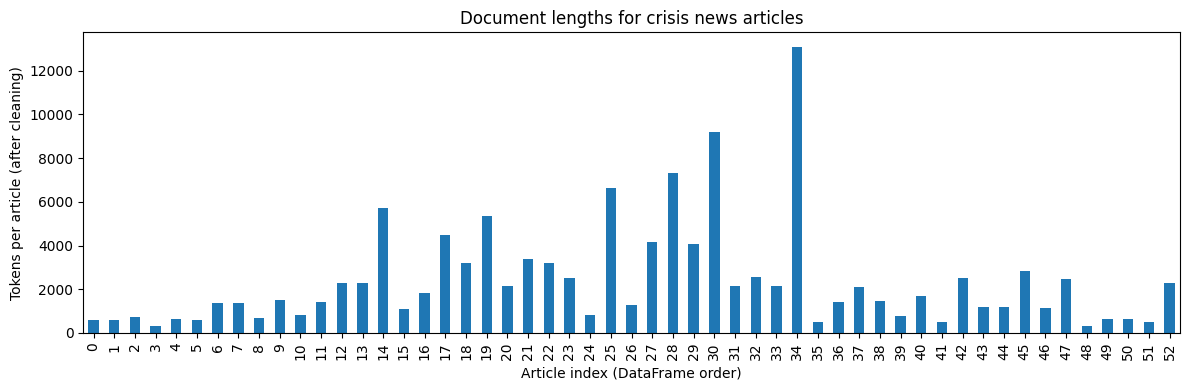

In [29]:
news_df["n_tokens"] = news_df["tokens"].apply(len)

ax = news_df.plot(
    y="n_tokens",
    kind="bar",
    figsize=(12, 4),
    legend=False
)

ax.set_ylabel("Tokens per article (after cleaning)")
ax.set_xlabel("Article index (DataFrame order)")
ax.set_title("Document lengths for crisis news articles")
plt.tight_layout()
plt.show()

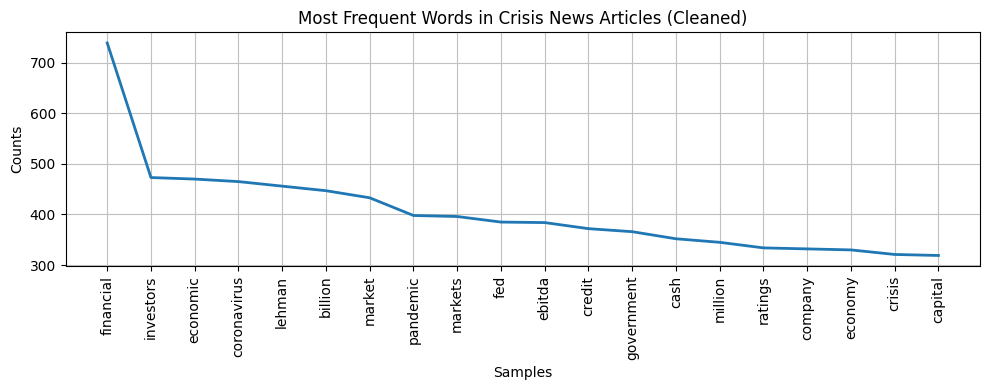

In [30]:


from nltk import FreqDist
import matplotlib.pyplot as plt

# Flatten all tokens from all articles into a single list
all_tokens = [t for toks in news_df["tokens"] for t in toks]

# Build frequency distribution
fdist = FreqDist(all_tokens)

# Visualize (optional)
plt.figure(figsize=(10, 4))
fdist.plot(20, cumulative=False)
plt.title("Most Frequent Words in Crisis News Articles (Cleaned)")
plt.tight_layout()
plt.show()




### 6.2 TF–IDF: Distinctive Crisis Vocabulary

**TF–IDF** = term frequency × inverse document frequency [(Krisel, 2023)](https://github.com/intro-to-text-analysis-SIPA-S23/syllabus)

TF–IDF highlights words that are  frequent **and** specific to a document.

The result shows that 2008 uses technical, institution-focused language rather than emotionally charged words; and 2020 focuses on public-health data, not market panic, leading to neutral financial tone; and 2023 repeatedly uses explicit crisis vocabulary (crisis, bank run, regulators, deposit flight), which VADER interprets as more negative—even though the actual economic impact was smaller.

From articles to term–document matrix

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1) Create a TF-IDF vectorizer
# min_df=2 → ignore words that appear in fewer than 2 documents (articles)
tfidf = TfidfVectorizer(min_df=2)

# 2) Fit the vectorizer on the cleaned article texts and transform them
# Each row = one article
# Each column = one term (a word in the vocabulary)
# Each cell value = TF-IDF weight of that term in that article
X_tfidf = tfidf.fit_transform(news_df["text_clean"])

# 3) Get the list of all terms (the vocabulary)
terms = np.array(tfidf.get_feature_names_out())

# 4) Check the shape of the TF-IDF matrix and vocabulary size
print("X_tfidf shape:", X_tfidf.shape)  # (n_articles, n_terms)
print("Number of unique terms:", len(terms))


X_tfidf shape: (53, 5257)
Number of unique terms: 5257


Function: top TF-IDF terms for a single article

In [32]:
def top_tfidf_terms_for_doc(doc_idx, top_n=12):
    """
    Return the top-n TF-IDF terms for a single article.

    doc_idx: integer index of the article in df
    top_n: number of top terms to return
    """
    # Row vector of TF-IDF scores for this article
    row = X_tfidf.getrow(doc_idx).toarray().ravel()

    # Indices of the top-n highest TF-IDF scores (most distinctive terms)
    top_idx = row.argsort()[::-1][:top_n]

    # Return list of (term, score) pairs
    return list(zip(terms[top_idx], row[top_idx]))


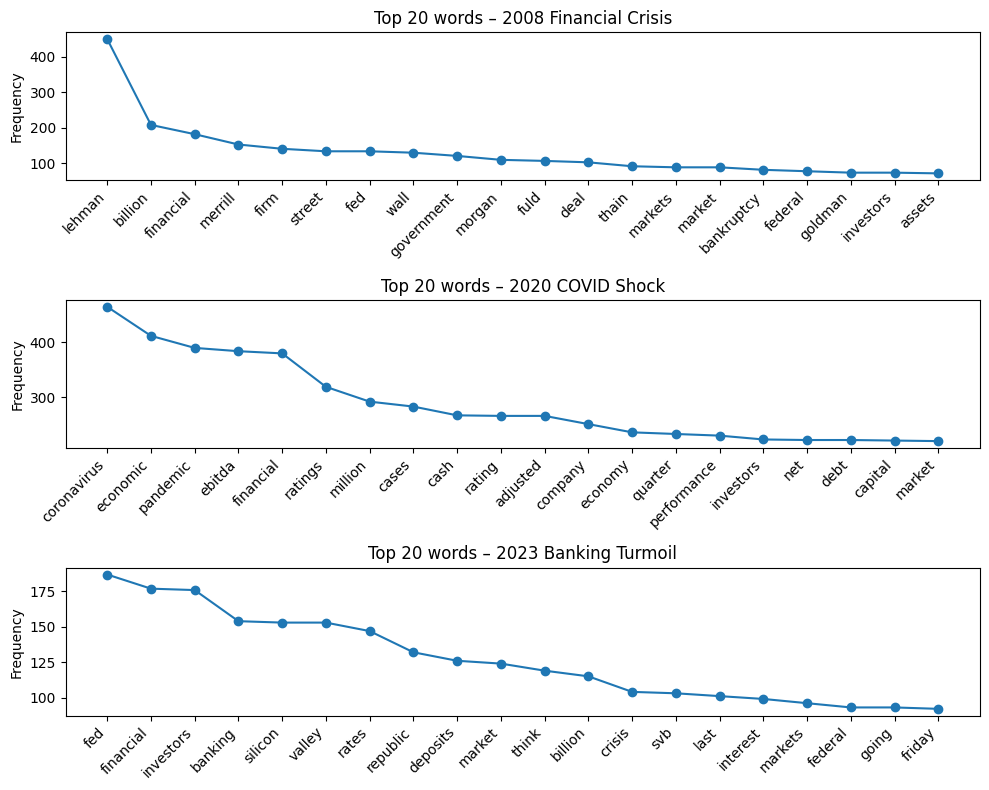

In [33]:
# Period order and label mapping
period_order = ["2008_crisis", "2020_covid", "2023_banking"]
label_map = {
    "2008_crisis": "2008 Financial Crisis",
    "2020_covid": "2020 COVID Shock",
    "2023_banking": "2023 Banking Turmoil"
}

# Create subplots: 3 rows, 1 column
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharey=False)

for ax, period in zip(axes, period_order):
    # Subset tokens for this period
    subset = news_df[news_df["period"] == period]

    # Flatten tokens for all articles in this period
    tokens_period = [t for toks in subset["tokens"] for t in toks]

    # Build frequency distribution
    fdist_period = FreqDist(tokens_period)

    # Get top 20 most frequent words
    common = fdist_period.most_common(20)
    if not common:
        # In case some period has no data
        ax.set_title(f"{label_map.get(period, period)} (no data)")
        ax.axis("off")
        continue

    words = [w for w, _ in common]
    counts = [c for _, c in common]

    # Plot as折线图 (line chart with markers)
    ax.plot(range(len(words)), counts, marker="o")
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right")

    ax.set_title(f"Top 20 words – {label_map.get(period, period)}")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

# Build one "mega document" per crisis period by concatenating all cleaned texts
period_corpus = (
    news_df
    .groupby("period")["text_clean"]
    .apply(lambda texts: " ".join(texts))   # concatenate all articles in the same period
    .reset_index()
    .rename(columns={"text_clean": "doc_text"})
)

period_corpus


,period,doc_text
0,2008_crisis,washington marketwatch barclays plc two leadin...
1,2020_covid,novel coronavirus spreads across economists re...
2,2023_banking,crisis svb financial holding company silicon v...


In [35]:
# Create a TF-IDF vectorizer for the period-level documents
# min_df=1 → keep any term that appears in at least one period
tfidf_period = TfidfVectorizer(min_df=1)

# Fit on the 3 documents (one per period) and transform
X_period = tfidf_period.fit_transform(period_corpus["doc_text"])

# Vocabulary: list of all terms
terms_period = np.array(tfidf_period.get_feature_names_out())

print("X_period shape (n_periods, n_terms):", X_period.shape)
print("Number of unique terms:", len(terms_period))

# Map row index → period label, for convenience
idx_to_period = period_corpus["period"].tolist()
idx_to_period


X_period shape (n_periods, n_terms): (3, 10371)
Number of unique terms: 10371


['2008_crisis', '2020_covid', '2023_banking']

In [36]:
def top_tfidf_terms_for_period(period_label, top_n=20):
    """
    Return the top-n TF-IDF terms for a given crisis period.

    period_label: e.g. '2008_crisis', '2020_covid', '2023_banking'
    top_n: number of top terms to return
    """
    # Find the row index corresponding to this period
    try:
        row_idx = idx_to_period.index(period_label)
    except ValueError:
        raise ValueError(f"Unknown period label: {period_label}. Available: {idx_to_period}")

    # Get the TF-IDF vector for this period and convert to dense array
    row = X_period.getrow(row_idx).toarray().ravel()

    # Indices of the top-n highest TF-IDF scores (most distinctive terms)
    top_idx = row.argsort()[::-1][:top_n]

    # Build a DataFrame for easier viewing / exporting
    out = pd.DataFrame({
        "term": terms_period[top_idx],
        "tfidf": row[top_idx]
    })

    return out


In [37]:
for p in idx_to_period:
    print(f"\n===== Top TF-IDF terms for period: {p} =====")
    top_terms = top_tfidf_terms_for_period(p, top_n=20)
    print(top_terms.to_string(index=False))



===== Top TF-IDF terms for period: 2008_crisis =====
      term    tfidf
    lehman 0.560999
   merrill 0.251358
   billion 0.201823
 financial 0.176595
      fuld 0.175786
     thain 0.151144
      firm 0.136813
    street 0.130020
       fed 0.130020
      wall 0.126139
government 0.117407
     lewis 0.111715
    morgan 0.106733
      deal 0.099941
   markets 0.086357
    market 0.086357
bankruptcy 0.079565
   paulson 0.078857
       aig 0.076216
   federal 0.075684

===== Top TF-IDF terms for period: 2020_covid =====
        term    tfidf
 coronavirus 0.287802
      ebitda 0.237668
    pandemic 0.183577
    economic 0.150606
   financial 0.138909
      rating 0.125209
    adjusted 0.125209
     ratings 0.116610
     funeral 0.110788
     million 0.106740
       cases 0.103450
        cash 0.097602
    cemetery 0.096553
consolidated 0.095315
     company 0.091753
     economy 0.086270
  infections 0.085412
     quarter 0.085173
 performance 0.084076
   investors 0.081517

===== Top 

In [38]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1) Compute cosine similarity matrix between all articles
# Each row/column corresponds to one article in news_df
sim = cosine_similarity(X_tfidf)   # shape: (n_articles, n_articles)

# 2) Choose a target article: here we use the last one (e.g., most recent)
target = len(news_df) - 1

# Build a list of (index, similarity) for all other articles
pairs = [(i, sim[target, i]) for i in range(len(news_df)) if i != target]

# Sort by similarity score (descending) and keep top 5 most similar
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[:5]

print("Target article:")
print(f"  idx={target}, period={news_df.loc[target, 'period']},")
print(f"  Headline: {news_df.loc[target, 'Headline'][:120]}",
      "..." if len(str(news_df.loc[target, 'Headline'])) > 120 else "")

print("\nMost similar articles to the target (by cosine similarity):")
for idx, score in pairs_sorted:
    headline = str(news_df.loc[idx, "Headline"])
    print(f"  idx={idx:3d} | period={news_df.loc[idx, 'period']:12s} "
          f"(cosine={score:.3f})")
    print(f"     Headline: {headline[:120]}",
          "..." if len(headline) > 120 else "")


Target article:
  idx=52, period=2023_banking,
  Headline: MarketWatch - Have Regulators Saved the U.S. Economy from Contagion? 

Most similar articles to the target (by cosine similarity):
  idx= 47 | period=2023_banking (cosine=0.400)
     Headline: MarketWatch - Digging Into the Banking Crisis and Debt-Limit Standoff 
  idx= 45 | period=2023_banking (cosine=0.331)
     Headline: Stocks to Watch: Mayhem in the Markets 
  idx= 48 | period=2023_banking (cosine=0.262)
     Headline: Pro Take: The Fed Hits Inflation With Ninth Rate Hike as Banks Reel; A ‘small number of banks' have problems but the U.S ...
  idx= 38 | period=2023_banking (cosine=0.253)
     Headline: Wall Street Braces for the Next Silicon Valley Bank -- Update 
  idx= 44 | period=2023_banking (cosine=0.251)
     Headline: First Republic, SVB, Credit Suisse Show How Higher Interest Rates Caught Up With Banks -- WSJ 


PCA 2D projection

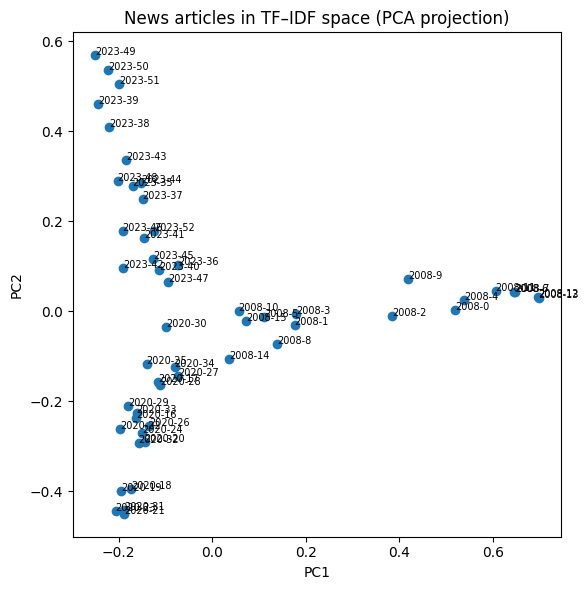

,Headline,period,PC1,PC2
0,Potential Lehman buyers balking; Unwilling to ...,2008_crisis,0.519678,0.001463
1,=DJ UPDATE: WSJ BLOG/Washington Wire: Candidat...,2008_crisis,0.175929,-0.031090
2,=DJ AT A GLANCE: European Bks Plunge On Lehman...,2008_crisis,0.383802,-0.012006
3,European Bank Shares Seen Lower After Lehman C...,2008_crisis,0.178476,-0.007165
4,Lehman files for bankruptcy protection; Wall S...,2008_crisis,0.538376,0.023691


In [39]:
# 3) 2D PCA projection (OK to densify if the corpus is small)
pca = PCA(n_components=2, random_state=42)

# Convert sparse TF-IDF matrix to dense array for PCA
coords = pca.fit_transform(X_tfidf.toarray())  # shape: (n_articles, 2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coords[:, 0], coords[:, 1])

# Annotate each point with a short label: period + index
for i, row in news_df.iterrows():
    label = f"{row['period'][:4]}-{i}"  # e.g. "2008-0", "2020-12"
    ax.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=7)

ax.set_title("News articles in TF–IDF space (PCA projection)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

# Optional: inspect coordinates table
pca_coords_df = news_df[["Headline", "period"]].assign(
    PC1=coords[:, 0],
    PC2=coords[:, 1]
)
pca_coords_df.head()


Wordcloud visualization

In [40]:
# !pip -q install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

# Build one "mega document" per crisis period by concatenating all cleaned texts
period_corpus = (
    news_df
    .groupby("period")["text_clean"]
    .apply(lambda texts: " ".join(texts))
    .reset_index()
    .rename(columns={"text_clean": "doc_text"})
)

period_corpus


,period,doc_text
0,2008_crisis,washington marketwatch barclays plc two leadin...
1,2020_covid,novel coronavirus spreads across economists re...
2,2023_banking,crisis svb financial holding company silicon v...


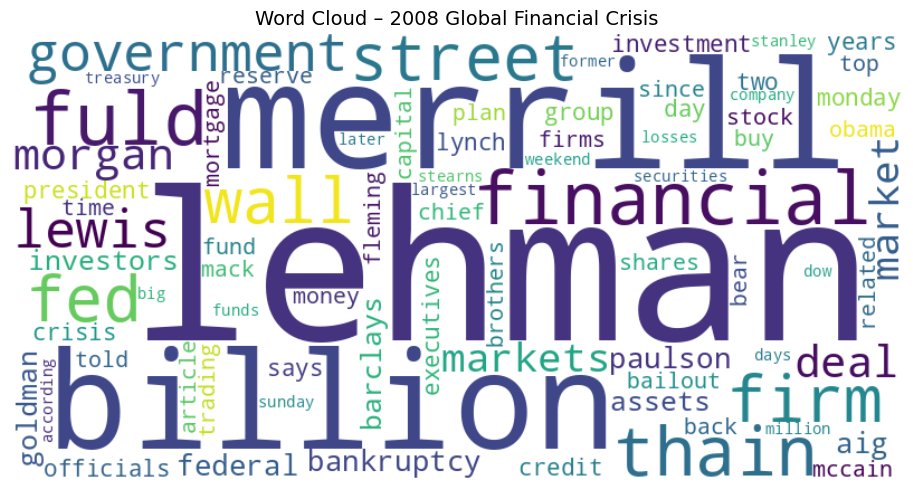

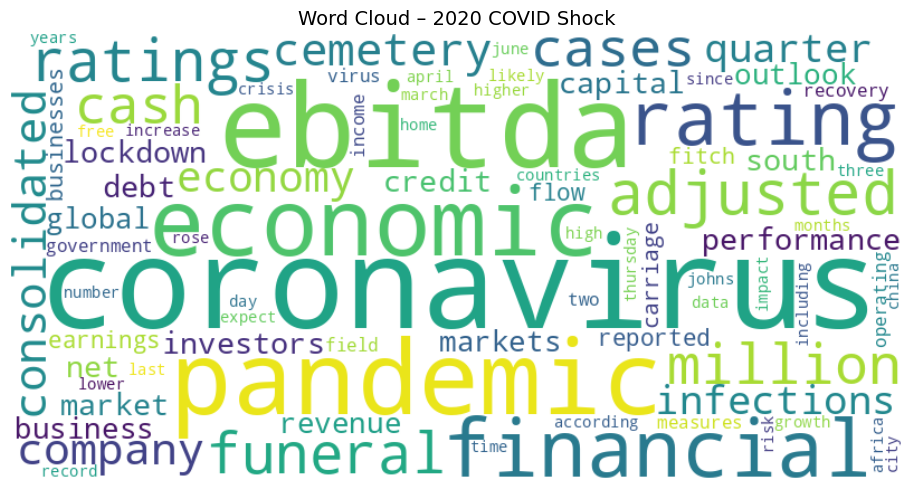

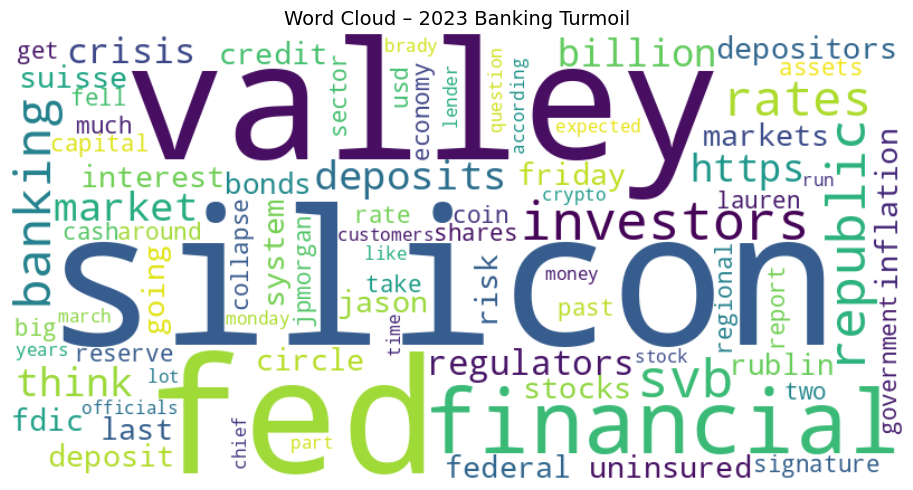

In [42]:
# labels for each period (for plot titles)
label_map = {
    "2008_crisis": "2008 Global Financial Crisis",
    "2020_covid": "2020 COVID Shock",
    "2023_banking": "2023 Banking Turmoil"
}

# Choose how many top TF-IDF terms to include in each word cloud
TOP_N = 80

# Loop over all periods in period_corpus
for period_label in idx_to_period:
    # Get top TF-IDF terms for this period as a DataFrame: columns = ['term', 'tfidf']
    top_terms_df = top_tfidf_terms_for_period(period_label, top_n=TOP_N)

    # Convert to dict: {term: tfidf_score}
    wc_data = dict(zip(top_terms_df["term"], top_terms_df["tfidf"]))

    # Create the word cloud object
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
        # You can specify font_path=... if you ever have non-ASCII text
    )
    wc.generate_from_frequencies(wc_data)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")

    title = label_map.get(period_label, period_label)
    plt.title(f"Word Cloud – {title}", fontsize=14)
    plt.tight_layout()
    plt.show()


## 7. Conclusion

In this project, I used VADER and FinBERT sentiment analysis and TF-IDF—to study how financial news covers three crises: the 2008 Lehman collapse, the 2020 COVID shock, and the 2023 U.S. regional banking turmoil. The sentiment results aligns between VADER and FinBERT, but I only conducted passage level analysis with FinBERT due to the limit of CPU. Together,the result show that, on average, news tone stays close to neutral in all three periods, even though the context is highly stressful. All three episodes tilt negative overall, but the magnitudes are modest, which fits the idea that mainstream financial journalism aims for a relatively restrained style rather than emotional language. More interesting is the ranking of the sentence level result: in macro terms, we usually think 2008 > 2020 > 2023 in severity, but in my data the news sentiment is most negative in 2023, then 2008, and least negative in 2020.

TF-IDF helps explain why. 2008 coverage is dominated by the names of specific failing institutions (Lehman, Merrill, AIG, Fuld), reflecting a firm-level framing of the crisis. 2023 coverage, despite being a smaller shock, uses terms such as deposits, regulators, systemic risk, interest rates, and crisis, indicating a system-level framing that is more alarm-oriented.

This shift matters: even if fundamentals are stronger, system-focused narratives can heighten uncertainty, influence expectations, and amplify stress within financial markets. The results suggest that news sentiment and crisis framing should be viewed as part of the financial-stability information set for regulators and central banks.

Finally, this study provides preliminary evidence based on a relatively small corpus and a general-purpose sentiment model. Future work should
(1) scale the analysis to a broader news dataset, and
(2) apply FinBERT to sentence level analysis to see if the result still holds

Together, these extensions can deepen our understanding of how media language interacts with crisis dynamics and the expectations that shape them.

I used ChatGPT to help modify code and build this script.

Here are some examples of the prompts I used: "The first screenshot has three time periods. Please take another look. I'm asking how to explain this. Why are the emotions getting worse from 2008 to 2020 and then to 2023?", "help me use finBERT to do another sentiment analysis", "Could you help me look for any existing research in this area? What conclusions did they draw?"

Sharing my conversation here: https://chatgpt.com/share/69349982-c4d0-800f-bceb-608ba9ea3312
